# MovieLens Recommendation System

## Business Understanding

#### *Background:*

With the rapid growth of digital content, users today are exposed to thousands of movie options across streaming platforms. While this abundance provides variety, it also creates a challenge: users often struggle to find movies that match their preferences.

Recommendation systems have become essential tools for platforms like **Netflix and Amazon**, helping users discover relevant content based on their past behavior. **These systems improve user experience, increase engagement, and drive platform retention.**

**The dataset used in this project comes from the MovieLens dataset,** which contains user ratings and movie information. **It captures how users interact with movies through ratings, providing a strong foundation for building collaborative filtering models.**

Although this dataset is based on a global audience, **the modeling approach and insights can be applied to entertainment platforms in African markets, where personalized digital experiences are becoming increasingly important.**

---
#### *Objectives:*

The main objective of this project is to build a personalized movie recommendation system that predicts and suggests movies a user is likely to enjoy based on their past ratings.

More specifically, the project aims to:

 1. Identify patterns in user ratings that reflect individual movie preferences.

 2. Develop recommendation models using KNN and SVD collaborative filtering techniques.

 3. Predict user ratings for unseen movies and generate top 5 personalized recommendations.

 4. Evaluate model performance using RMSE and select the best-performing model.

 5. Provide insights into how recommendation systems can improve user engagement and satisfaction.

Understanding these patterns is important because **poor content discovery can reduce user engagement, increase churn, and limit the value users derive from a platform.**

---

#### *Why this matters:*

 - Personalized recommendation systems help users quickly find content that matches their interests, reducing decision fatigue and improving overall experience.
 - For businesses, better recommendations lead to increased user engagement, longer session times, and higher retention rates.
 - In growing digital markets across Africa, where streaming services and online platforms are expanding, recommendation systems can provide a competitive advantage.
 - By leveraging user data effectively, platforms can deliver more relevant content, improving both customer satisfaction and business performance.

 ---

#### *Key Stakeholders:*

1. **MovieLens / GroupLens Research**
     - Provides the dataset and supports research in recommendation systems.

2. **Streaming Platforms (e.g., Netflix, Showmax)**
     - Use recommendation systems to personalize user experiences and retain subscribers.

3. **Content Providers and Media Companies**
     - Benefit from improved visibility of their content through personalized recommendations.

4. **End Users**
     - Receive tailored movie suggestions, improving satisfaction and ease of content discovery.

Insights from this project could help these stakeholders:

 - Improve recommendation accuracy

 - Enhance user engagement

 - Deliver more personalized digital experiences

---

#### *Problem Description:*

Despite having access to large movie libraries, users often find it difficult to identify movies that match their preferences. Without personalization, users may spend excessive time searching for content or abandon the platform altogether.

Platforms also face challenges in understanding user preferences, especially when dealing with large volumes of data and diverse user tastes.

Without an effective recommendation system:

 - Users may experience information overload

 - Engagement levels may decline

 - Platforms may struggle to retain users

This project therefore seeks to answer the following key question:

**Can historical user ratings be used to accurately predict preferences and generate personalized movie recommendations for users?**

---
## Data Understanding

The datasets that are being used in this project are :
      
* **movies.csv** : This dataset holds the movie title and the genres associated to the respective movies all numbered up with their movieID

* **ratings.csv** : This dataset holds the userID, movieID and their corresponding ratings as well as the movies' timestamp.
    

In [2]:
# Importing and loading in the movie dataset
import pandas as pd

movies_df = pd.read_csv('./Data/movies.csv')
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
# Loading in the ratings dataset
ratings_df = pd.read_csv('./Data/ratings.csv')
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
# Checking for null values in both datasets
movies_df.isna().sum(), ratings_df.isna().sum()

(movieId    0
 title      0
 genres     0
 dtype: int64,
 userId       0
 movieId      0
 rating       0
 timestamp    0
 dtype: int64)

In [5]:
# Checking for duplicated values in both datasets
movies_df.duplicated().sum(), ratings_df.duplicated().sum()

(0, 0)

## Exploratory Data Analysis (EDA)

In this section, we explore the structure and characteristics of the dataset to better understand:

- The number of unique users and movies
- The distribution of ratings
- User activity levels
- Movie popularity

These insights will help guide modeling decisions and highlight potential challenges such as data sparsity.

In [6]:
# Preparing the dataset for EDA
# Combining the two dataframes
combined_df = pd.merge(movies_df, ratings_df, on=['movieId'])

# Cleaning the Genre column
combined_df['genres'] = combined_df['genres'].str.split('|')
combined_df_exploded = combined_df.explode('genres')

combined_df_exploded.head()

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure,1,4.0,964982703
0,1,Toy Story (1995),Animation,1,4.0,964982703
0,1,Toy Story (1995),Children,1,4.0,964982703
0,1,Toy Story (1995),Comedy,1,4.0,964982703
0,1,Toy Story (1995),Fantasy,1,4.0,964982703


In [7]:
# Dropping the Movies with no genre
combined_df_exploded = combined_df_exploded[combined_df_exploded['genres'] != '(no genres listed)']

# Grouping the Genres by Average Rating
avg_rating_per_genre = combined_df_exploded.groupby('genres')['rating'].mean().sort_values()
avg_rating_per_genre

genres
Horror         3.258195
Comedy         3.384721
Children       3.412956
Action         3.447984
Sci-Fi         3.455721
Fantasy        3.491001
Thriller       3.493706
Romance        3.506511
Adventure      3.508609
Musical        3.563678
Western        3.583938
IMAX           3.618335
Animation      3.629937
Mystery        3.632460
Drama          3.656184
Crime          3.658294
Documentary    3.797785
War            3.808294
Film-Noir      3.920115
Name: rating, dtype: float64

### 1.) Average Rating per Genre

This plot was used to compare how different movie genres are rated on average by users. It helps identify which genres are generally more preferred.


#### *Why this matters:*
- Helps understand **content preferences** at a genre level.
- Can inform recommendation logic (e.g., prioritize highly rated genres for users).
- Useful for improving recommendation relevance beyond just user similarity.

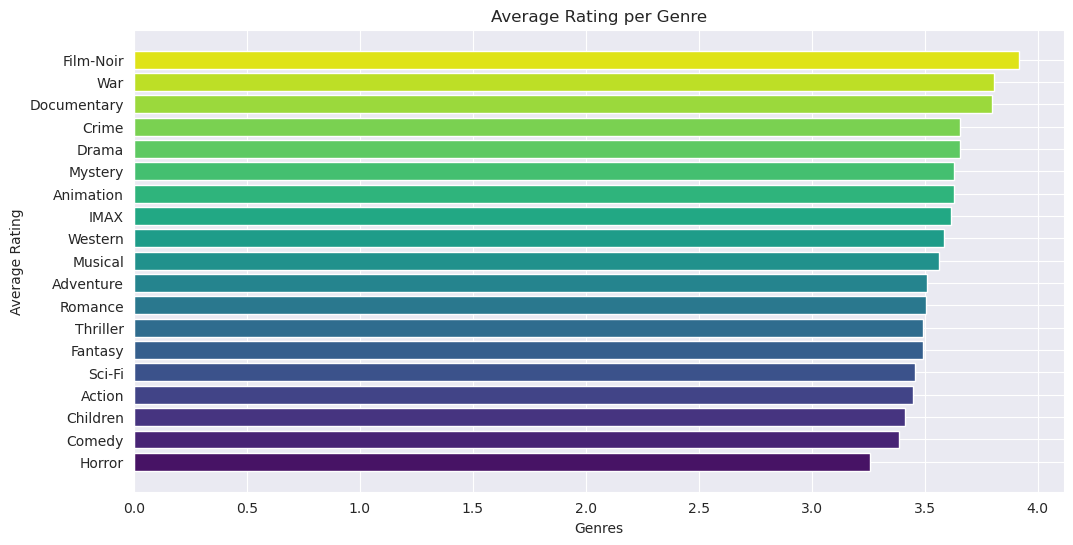

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

palette = sns.color_palette('viridis', len(avg_rating_per_genre))
plt.figure(figsize=(12,6))
plt.barh(avg_rating_per_genre.index, avg_rating_per_genre.values, color=palette)
plt.xlabel('Genres')
plt.ylabel('Average Rating')
plt.title('Average Rating per Genre')
plt.show()


#### Key Insights:
- Some genres consistently receive higher average ratings than others.

- Genres with lower average ratings may indicate less user satisfaction or niche appeal.

- Differences across genres highlight variation in user preferences.


### 2.) Number of Ratings per User vs Average Rating

This scatter plot explores the relationship between how active a user is (number of ratings) and their average rating behavior.

#### *Why this matters:*
- Highlights **user behavior differences**, which impact recommendation accuracy.

- Highly active users provide more reliable data for collaborative filtering.

- Less active users contribute to the **cold start problem**, making recommendations harder.

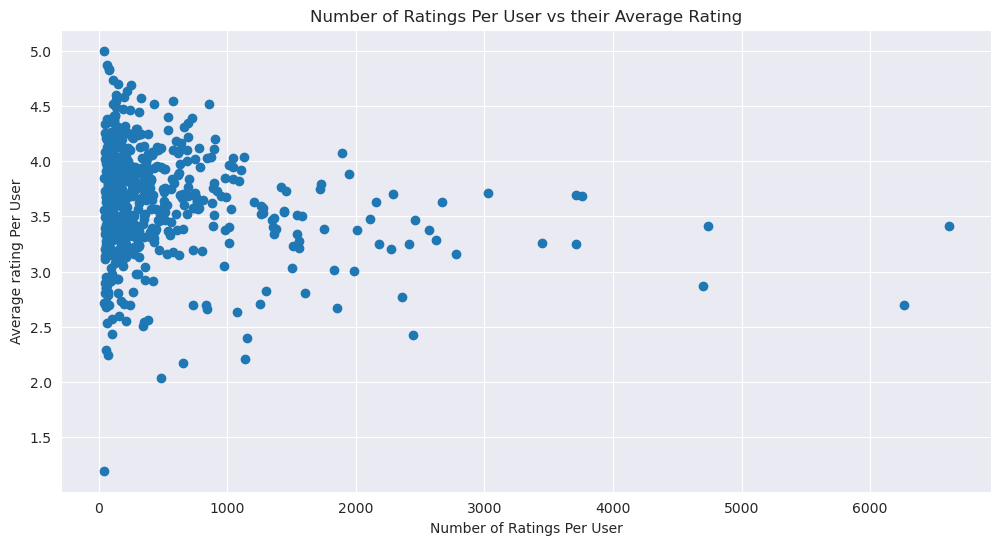

In [9]:
# Number of Ratings per User
num_of_ratings_per_user = combined_df_exploded.groupby('userId')['rating'].count()

# Average Rating per User
avg_rating_per_user = combined_df_exploded.groupby('userId')['rating'].mean()

# Scatterplot
plt.figure(figsize=(12,6))
plt.scatter(num_of_ratings_per_user.values, avg_rating_per_user.values)
plt.xlabel('Number of Ratings Per User')
plt.ylabel('Average rating Per User')
plt.title('Number of Ratings Per User vs their Average Rating')
plt.show()

#### Key Insights:
- Most users cluster around a lower number of ratings, indicating low activity.
- Some users are highly active, contributing many ratings.
- Average ratings vary across users, showing that some users tend to rate higher or lower than others.

### 3.) Distribution of Number of Ratings per Genre

This plot shows how frequently each genre appears in user ratings, helping identify which genres are most popular.


#### *Why this matters:*
- Popular genres may dominate recommendations if not controlled.

- Models may become biased toward frequently rated genres.

- Important for ensuring **diversity in recommendations**.

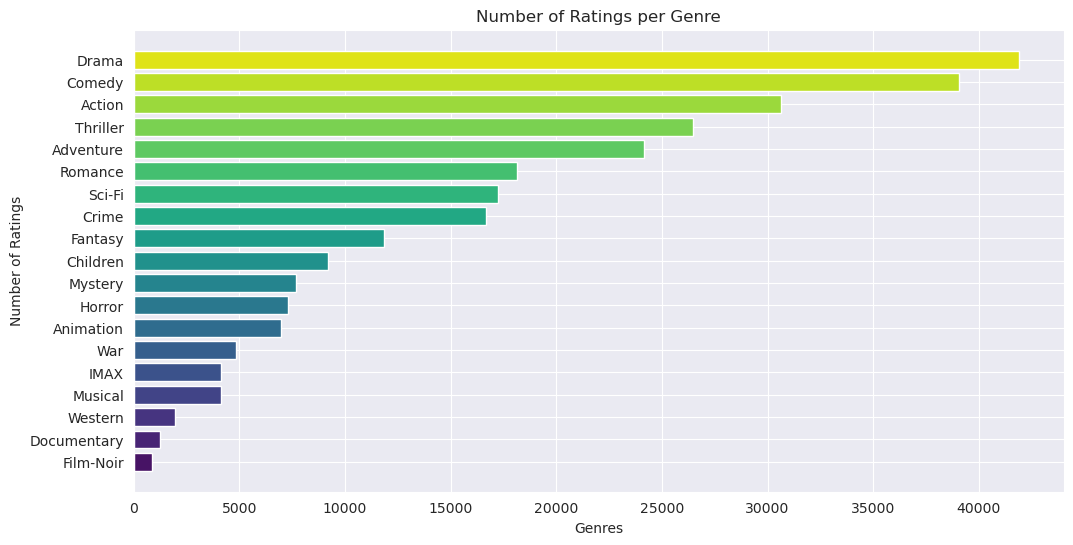

In [10]:
# Number of ratings per genre
num_of_ratings_per_genre = combined_df_exploded.groupby('genres')['rating'].count().sort_values()

# Number of Ratings per Genre Horizontal Bar Chart
plt.figure(figsize=(12,6))
plt.barh(num_of_ratings_per_genre.index, num_of_ratings_per_genre.values, color=palette)
plt.xlabel('Genres')
plt.ylabel('Number of Ratings')
plt.title('Number of Ratings per Genre')
plt.show()

#### Key Insights:
- Some genres receive significantly more ratings than others.
- This indicates higher popularity or wider audience appeal.
- Less-rated genres may represent niche or less-watched content.

### 4. Number of Ratings per Genre vs the Average Rating
### Genre Popularity vs Average Rating


This scatter plot examines the relationship between a genre's popularity (number of ratings) and its average rating.

#### *Why this matters:*
- Helps distinguish between **popular content** and **high-quality content**.

- A good recommendation system should balance both.

- Prevents the model from recommending only popular movies while ignoring highly rated niche ones.

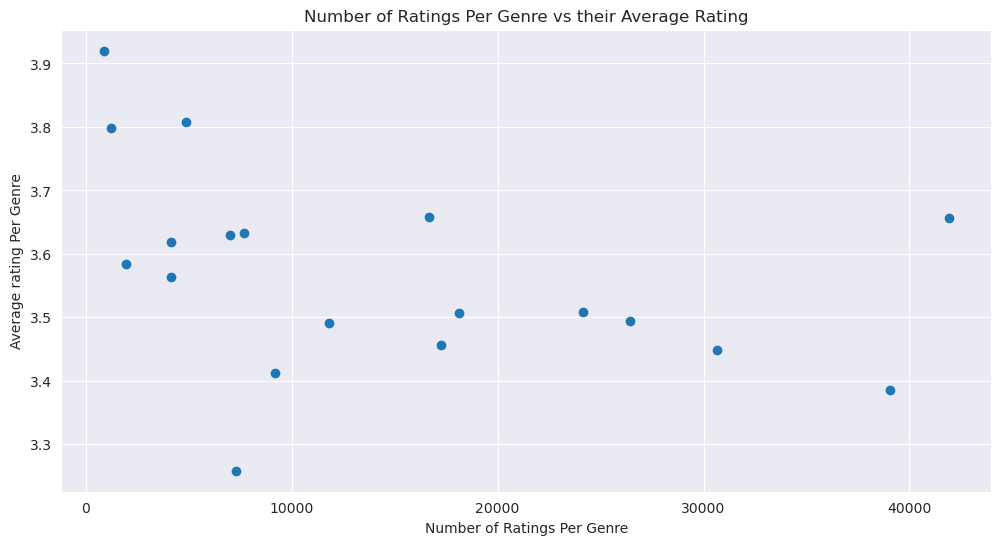

In [11]:
num_of_ratings_per_genre = num_of_ratings_per_genre.sort_index()
avg_rating_per_genre = avg_rating_per_genre.sort_index()

plt.figure(figsize=(12,6))
plt.scatter(num_of_ratings_per_genre.values, avg_rating_per_genre.values)
plt.xlabel('Number of Ratings Per Genre')
plt.ylabel('Average rating Per Genre')
plt.title('Number of Ratings Per Genre vs their Average Rating')
plt.show()

#### Key Insights:
- Some genres are highly rated but not very popular.
- Others are very popular but have average or moderate ratings.
- There is no perfect correlation between popularity and quality.

In [12]:
new_ratings_df = ratings_df.drop('timestamp', axis=1)
new_ratings_df.head()

,userId,movieId,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0


In [13]:
user_id_range = (new_ratings_df['userId'].min(), new_ratings_df['userId'].max())
movie_id_range = (new_ratings_df['movieId'].min(), new_ratings_df['movieId'].max())
print('User ID range: ', user_id_range)
f"Movie ID range: {movie_id_range}"

User ID range:  (1, 610)


'Movie ID range: (1, 193609)'

In [14]:
new_ratings_df['rating'].value_counts().sort_index()

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

## Model Building

---
### Goal of This Section

The goal of this section is to build and evaluate collaborative filtering models that can predict user ratings for movies they have not yet seen. These predicted ratings will later be used to generate personalized movie recommendations.

---

### Why Use the Surprise Library?

The **Surprise** library is specifically designed for building and evaluating recommendation systems based on user-item interactions.

It is used in this project because:
- It provides built-in implementations of collaborative filtering algorithms

- It handles **user-item rating matrices efficiently**

- It includes tools for **model evaluation** such as RMSE

- It supports **hyperparameter tuning** through GridSearchCV

---

### Models to Be Built :

The following models will be implemented and compared:

- **KNNBasic** - baseline similarity-based model  
- **KNNWithMeans** - accounts for user rating biases  
- **KNNWithZScore** - normalizes ratings using standard deviation  
- **SVD** - matrix factorization model that learns latent features  

Each model will be evaluated using **RMSE**, and the best-performing model will be selected for generating recommendations.

In [15]:
from surprise import Reader, Dataset

data = Dataset.load_from_df(new_ratings_df, Reader(rating_scale=(0, 5)))

In [16]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data, test_size=0.2, random_state=2026)

In [17]:
# Importing relevant libraries
from surprise.model_selection import GridSearchCV
from surprise.prediction_algorithms import SVD, KNNWithMeans, KNNBasic, KNNBaseline
from surprise import accuracy
import numpy as np

### a) SVD


While KNN models rely on similarity between users or items, they can struggle with highly sparse data.

To address this, we now implement a **matrix factorization approach (SVD)**, which captures hidden patterns in the data.

---

### Singular Value Decomposition (SVD)

#### *Why this model is built:*
SVD is a **matrix factorization technique** that decomposes the user-item matrix into latent features.

Instead of relying on direct similarity, it:
- Learns hidden factors that influence user preferences
- Represents users and movies in a lower-dimensional
space

---

#### Why *SVD is important:*
- Handles **sparse data more effectively**
- Captures **complex relationships** between users and movies
- Often provides **better accuracy** than neighborhood-based methods

In [18]:
## Perform a gridsearch with SVD
# This cell may take several minutes to run
param_grid = {
    'n_factors': [50, 100],
    'n_epochs': [20, 50],
    'lr_all': [0.005, 0.0005],
    'reg_all': [0.02, 0.04]
}
svd_model = GridSearchCV(
    algo_class=SVD,
    param_grid=param_grid,
    cv=3,
    refit=True,
    measures=['rmse']
)
svd_model.fit(data)

In [19]:
# RMSE during cross-validation
print(svd_model.best_score['rmse'])
svd_model.best_params['rmse']

0.8719379606443808


{'n_factors': 100, 'n_epochs': 50, 'lr_all': 0.005, 'reg_all': 0.04}

In [20]:
# RMSE on test set
svd = SVD(
    n_factors=svd_model.best_params['rmse']['n_factors'],
    n_epochs=svd_model.best_params['rmse']['n_epochs'],
    lr_all=svd_model.best_params['rmse']['lr_all'],
    reg_all=svd_model.best_params['rmse']['reg_all']
)
svd.fit(trainset)
predictions = svd.test(testset)
svd_accuracy = accuracy.rmse(predictions)
svd_accuracy

RMSE: 0.8695


0.8695280475138065

*Breakdown:*

The RMSE for SVD indicates how well the model captures underlying patterns in user preferences.

---

*Interpretation:*

- A lower RMSE compared to KNN models suggests that **latent factor modeling is more effective**

- If SVD significantly outperforms KNN, it becomes the preferred model for recommendations

This step determines the final model to be used in the system.

### b) KNNBasic
---

KNNBasic is the most straightforward implementation of collaborative filtering using similarity between users or items.

It is built as a **baseline model** to:
- Establish a reference point for performance
- Understand how well simple similarity-based recommendations perform

This model predicts ratings based purely on **neighbor similarity**, without adjusting for user or item rating biases.

In [21]:
# Cross validating with KNNBasic
param_grid = {
    'k': [40, 50],
    'min_k': [1, 5],
    'sim_options': {
        'name': ['cosine', 'pearson'],
        'user_based': [True]
    }
}
knn_basic_model = GridSearchCV(
    algo_class=KNNBasic,
    param_grid=param_grid,
    refit=True,
    measures=['rmse'],
    cv=3
)
knn_basic_model.fit(data)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Comput

In [22]:
# RMSE during cross-validation
print(knn_basic_model.best_score['rmse'])
knn_basic_model.best_params['rmse']

0.9760557018669962


{'k': 50, 'min_k': 5, 'sim_options': {'name': 'cosine', 'user_based': True}}

In [23]:
# RMSE on test set
knn_basic = KNNBasic(
    k=knn_basic_model.best_params['rmse']['k'],
    min_k=knn_basic_model.best_params['rmse']['min_k'],
    sim_options=knn_basic_model.best_params['rmse']['sim_options']
)
knn_basic.fit(trainset)
predictions = knn_basic.test(testset)
knn_basic_accuracy = accuracy.rmse(predictions)
knn_basic_accuracy

Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 0.9759


0.9758793603369795

---
*Breakdown:*

The performance of the KNNBasic model is measured using **Root Mean Squared Error (RMSE)**.

The RMSE being **0.9757** indicates that the KNNBasic model has larger prediction errors making it not to be very reliable.

### c) KNNBaseline

#### *Why this model is built:*
KNNBaseline is an advanced variation of KNN that incorporates **baseline estimates** into the prediction process.

Instead of relying only on similarity, it adjusts predictions using:
- The overall average rating
- User-specific bias (some users rate higher/lower)
- Item-specific bias (some movies are generally rated higher/lower)

This helps correct systematic differences in rating behavior.

---

#### *Why this is important:*
 - Some movies are universally popular, while others are not
 - Some users consistently give high or low ratings
 - Ignoring these biases can reduce prediction accuracy

KNNBaseline improves upon earlier KNN models by combining:
 - **Bias correction**
 - **Similarity-based learning**

---

#### *Difference from previous KNN models:*
- **KNNBasic** → No bias adjustment  
- **KNNWithMeans** → Adjusts for user average  
- **KNNBaseline** → Uses **global, user, and item biases**

This makes it one of the most robust neighborhood-based methods.

In [24]:
# Cross validating with KNNBaseline
param_grid = {
    'k': [30, 40],
    'min_k': [5, 10],
    'sim_options': {
        'name': ['cosine', 'pearson'],
        'user_based': [True]
    }
}
knn_baseline_model = GridSearchCV(
    algo_class=KNNBaseline,
    param_grid=param_grid,
    refit=True,
    measures=['rmse'],
    cv=3
)
knn_baseline_model.fit(data)

Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Com

In [25]:
# RMSE during cross validation
print(knn_baseline_model.best_score['rmse'])
knn_baseline_model.best_params['rmse']

0.8708005389660317


{'k': 40, 'min_k': 10, 'sim_options': {'name': 'pearson', 'user_based': True}}

In [26]:
# RMSE on test set
knn_baseline = KNNBaseline(
    k=knn_baseline_model.best_params['rmse']['k'],
    min_k=knn_baseline_model.best_params['rmse']['min_k'],
    sim_options=knn_baseline_model.best_params['rmse']['sim_options']
)
knn_baseline.fit(trainset)
predictions = knn_baseline.test(testset)
knn_baseline_accuracy = accuracy.rmse(predictions)
knn_baseline_accuracy

Estimating biases using als...
Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 0.8714


0.8714494892675733

*Breakdown:*

The RMSE for KNNBaseline reflects how well incorporating baseline estimates improves prediction accuracy.

---

*Interpretation:*

The RMSE from the KNNBaseline model is **0.8714** suggests that **the bias correction significantly improves performance** as well as it indicates that **accounting for user and item effects is critical.**

---

*Key Insight:*
- This model often performs better because it separates:
  - General rating tendencies (bias)
  - Personalized preferences (similarity)

This balance makes KNNBaseline a strong candidate for recommendation tasks.

### d) KNNWithMeans
---

#### Why this model is built:
KNNWithMeans improves upon KNNBasic by accounting for **user rating bias**.

Some users tend to:
- Rate movies consistently higher
- Rate movies consistently lower

This model adjusts for those differences by subtracting the user's average rating before computing similarity.

---

#### Difference from KNNBasic:
- KNNBasic: Uses raw ratings
- KNNWithMeans: Adjusts ratings based on each user’s average

This leads to more personalized and accurate predictions.

In [27]:
# Cross validating with KNNWithMeans
param_grid = {
    'k': [30, 40],
    'min_k': [5, 10],
    'sim_options': {
        'name': ['cosine', 'pearson'],
        'user_based': [True]
    }
}
knn_with_means_model = GridSearchCV(
    algo_class=KNNWithMeans,
    param_grid=param_grid,
    refit=True,
    measures=['rmse'],
    cv=3
)
knn_with_means_model.fit(data)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Comput

In [28]:
# RMSE during cross validation
print(knn_with_means_model.best_score['rmse'])
knn_with_means_model.best_params['rmse']

0.8988535598686572


{'k': 40, 'min_k': 5, 'sim_options': {'name': 'pearson', 'user_based': True}}

In [29]:
# RMSE on test set
knn_with_means = KNNWithMeans(
    k=knn_with_means_model.best_params['rmse']['k'],
    min_k=knn_with_means_model.best_params['rmse']['min_k'],
    sim_options=knn_with_means_model.best_params['rmse']['sim_options']
)
knn_with_means.fit(trainset)
predictions = knn_with_means.test(testset)
knn_with_means_accuracy = accuracy.rmse(predictions)
knn_with_means_accuracy

Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 0.8987


0.8987463016333889

---
*Breakdown:*

The RMSE for this model indicates how well adjusting for user bias improves prediction accuracy.

---

*Interpretation:*

The KNNMeans model has attained a RMSE of **0.8987** suggesting that the added complexity of the model in comparison to the Basic model may not significantly improve predictions.

This comparison helps determine whether normalization adds value.

### e) Final Evaluation

## Final Model Comparison

After evaluating all models using RMSE:

- The model with the **lowest RMSE** is selected as the best-performing model
- This model provides the most accurate rating predictions

---

The selected model will be used to generate personalized movie recommendations.

In [30]:
# Store rmse scores for each model as the average of the cv and test rmses
scores = {
    svd: (svd_model.best_score['rmse'] + svd_accuracy) / 2,
    knn_basic: (knn_basic_model.best_score['rmse'] + knn_basic_accuracy) / 2,
    knn_baseline: (knn_baseline_model.best_score['rmse'] + knn_baseline_accuracy) / 2,
    knn_with_means: (knn_with_means_model.best_score['rmse'] + knn_with_means_accuracy) / 2
}

In [31]:
# Get the best model dynamically as the model with the least avg rmse
best_model = min(scores, key=lambda model: scores[model])
best_model

## Making Predictions

After training the models, the next step is to use them to **predict user ratings for movies they have not yet rated**.

The goal of prediction is to:
- Estimate how much a user would like unseen movies
- Fill in the missing values in the user-item matrix
- Enable personalized recommendations

---

This helps to :

- Transforms the model from a training tool into a **decision-making system**
- Allows us to move from “understanding data” to “generating value”
- Provides the foundation for ranking movies for each user

These predicted ratings are essential because recommendation systems rely on them to determine which movies should be suggested to users.

In [32]:
best_model.predict(1, 3)

Prediction(uid=1, iid=3, r_ui=None, est=4.147270343334536, details={'was_impossible': False})

## 4. Recommendation Functions

The recommendation function is designed to take the model’s predicted ratings and convert them into **actionable recommendations for users**.

Instead of just predicting ratings, we need a way to:
- Identify movies a user has not seen
- Predict ratings for those movies
- Rank them from highest to lowest
- Return the **top 5 most relevant movies**

---

### What we aim to achieve:

- Deliver **personalized movie suggestions** for each user
- Improve user experience by reducing search time
- Provide a practical output that can be integrated into a real application (e.g., Streamlit UI)

This function is the core of the recommendation system, as it connects model predictions to real user value.

### a) Recommendations for Existing Users


#### *Why this approach is used:*

For users who have already rated movies, we can leverage their historical data to generate **highly personalized recommendations**.

The model:
- Learns the user's preferences
- Identifies similar users or patterns
- Predicts ratings for unseen movies

---

#### *Importance to the user:*

- Provides recommendations tailored to individual tastes
- Increases satisfaction by suggesting relevant content
- Reduces time spent searching for movies

This is the most powerful use of collaborative filtering, as it uses real user behavior to drive recommendations.

In [33]:
def get_existing_user_recommendations(user_id, ratings_dataframe, movies_dataframe, best_model, k=5):
    """
    NB: This function takes in an already fitted model
    """

    # Get predictions for movies the user has not seen using the already fitted best model
    all_movie_ids = ratings_dataframe['movieId'].unique()
    user_movie_ids = ratings_dataframe['movieId'].loc[ratings_dataframe['userId'] == user_id].unique()
    predictions = [(movie_id, best_model.predict(user_id, movie_id).est) for movie_id in all_movie_ids if movie_id not in user_movie_ids]
    predictions.sort(key=lambda x: x[1], reverse=True)

    # Return the top k movie titles and the predicted rating
    top_k = predictions[:k]
    top_k_titles = [
        (movies_dataframe.loc[movies_dataframe['movieId'] == movie_id, 'title'].values[0], pred_rating)
        for movie_id, pred_rating in top_k
    ]
    return top_k_titles

In [34]:
get_existing_user_recommendations(1, new_ratings_df, movies_df, best_model=best_model)

[('Shawshank Redemption, The (1994)', 5),
 ('Departed, The (2006)', 5),
 ('Ex Machina (2015)', 5),
 ('Amadeus (1984)', 5),
 ('Bridge on the River Kwai, The (1957)', 5)]

### b.)Recommendations for New Users

#### *Why this approach is used:*

New users do not have any rating history, making it impossible to apply collaborative filtering directly.

This situation is known as the **cold start problem**.

To address this, recommendations are typically based on:
- Popular movies
- Highly rated movies
- General trends in the dataset

---

#### *Importance to the user:*

- Ensures that new users still receive meaningful recommendations
- Helps users engage with the platform from the start
- Encourages users to interact and provide ratings, enabling future personalization

Handling new users effectively is critical for user retention and system usability.

In [35]:
# Helper function to get a valid user id
def get_valid_user_id(ratings_dataframe):
    return ratings_dataframe['userId'].max() + 1

In [36]:
# Helper function to get k ratings from the user
def get_sample_ratings(user_id, movies_dataframe, samples_num=5):
    rated = 0
    sampled_indices = []
    ratings = []

    while rated < samples_num:
        remaining = movies_dataframe.drop(index=sampled_indices)
        sample = remaining.sample(1)
        sampled_indices.append(sample.index[0])
        print(f"Movie #{rated + 1}")
        rating = input(f"Rate this movie (from 0 - 5) '{sample['title'].values[0]}' (Click Enter if you have not seen it): ")

        if rating == '':
            continue
        elif float(rating) < 0 or float(rating) > 5:
            print("Please enter a valid rating (between 0 and 5)")
            continue

        ratings.append({
            'userId': user_id,
            'movieId': sample['movieId'].values[0],
            'rating': float(rating)
        })
        rated += 1

    return ratings

In [37]:
def get_new_user_recommendations(ratings_dataframe, movies_dataframe, the_best_model, num_samples=5, k=5):
    # First, give the new user a valid id
    new_user_id = get_valid_user_id(ratings_dataframe=ratings_dataframe)

    # Get sample ratings from the user to solve cold-start problem
    new_user_ratings = get_sample_ratings(new_user_id, movies_dataframe, num_samples)

    # Add these new ratings to the original dataframe
    new_user_ratings_df = pd.DataFrame(new_user_ratings)
    new_ratings_dataframe = pd.concat([ratings_dataframe, new_user_ratings_df], ignore_index=True)

    # Train the best model on the new ratings dataframe
    data = Dataset.load_from_df(new_ratings_dataframe, Reader(rating_scale=(0, 5)))
    trainset = data.build_full_trainset()
    the_best_model.fit(trainset)

    # Use this new ratings df and the fitted model to get recommendations
    return get_existing_user_recommendations(new_user_id, new_ratings_dataframe, movies_dataframe, the_best_model)


In [38]:
get_new_user_recommendations(new_ratings_df, movies_df, best_model)

Movie #1
Movie #2
Movie #3
Movie #4
Movie #5


[('Trial, The (Procès, Le) (1962)', 2.8066790381363393),
 ('Shawshank Redemption, The (1994)', 2.677785620367777),
 ('Streetcar Named Desire, A (1951)', 2.6753383295950064),
 ('Sound of Music, The (1965)', 2.6422088653744287),
 ('His Girl Friday (1940)', 2.640934147792006)]

---
#### Overall Impact

By combining prediction models with tailored recommendation strategies for both existing and new users, the system is able to:

- Provide personalized experiences where data is available
- Maintain usability even when user data is limited
- Deliver consistent value across different user types

This makes the recommendation system both practical and scalable for real-world applications.

---

## Conclusion

In this notebook, we successfully developed a movie recommendation system using collaborative filtering techniques.

Key achievements include:

- Building and comparing **KNN** and **SVD** models
- Evaluating model performance using **RMSE**
- Selecting the best-performing model
- Creating a function to generate personalized movie recommendations

This system demonstrates how user rating data can be used to improve content discovery and enhance user experience.


In [39]:
# Convert relevant dataframes to csv files for Tableau
combined_df_exploded.to_csv('./Data/combined_df_exploded.csv', index=False)
combined_df.to_csv('./Data/combined_df.csv', index=False)